In [1]:
import pandas as pd

##BE CAREFUL OF UPPER CASE TEXT

In [2]:
df = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/Nodes_test_mission.csv', encoding='cp1252')

# Split mission types into lists
df["Mission type"] = (
    df["Mission type"]
    .fillna("")
    .str.split(";")
    .apply(lambda x: [i.strip() for i in x if i.strip()])
)

In [3]:
# df_restoration = df[
#     df["Mission type"].apply(
#         lambda x: "restoration" in [m.lower() for m in x]
#     )
# ]

# df = df_restoration

In [4]:
mission_list = {}

for _, row in df.iterrows():
    for mission in row["Mission type"]:
        mission_list.setdefault(mission)

mission_list

{'government oversight': None,
 'regulatory and legal affairs': None,
 'restoration': None,
 'engineering': None,
 'capacity building and technical assistance': None,
 'education': None,
 'community engagement': None,
 'permitting': None,
 'research': None,
 'funding': None,
 'economic development': None,
 'advocacy and awareness': None,
 'monitoring and assessment': None,
 'land protection': None,
 'historical preservation': None}

In [5]:
import networkx as nx
from itertools import combinations

G = nx.Graph()

# Add nodes with organization type
for _, row in df.iterrows():
    G.add_node(
        row["Nodes"],
        org_type=row["Org type"]
    )

# Dictionary: mission -> organizations
mission_dict = {}

for _, row in df.iterrows():
    for mission in row["Mission type"]:
        mission_dict.setdefault(mission, []).append(row["Nodes"])

# Connect organizations sharing missions
for mission, orgs in mission_dict.items():

    for org1, org2 in combinations(orgs, 2):

        if G.has_edge(org1, org2):
            G[org1][org2]["weight"] += 1
        else:
            G.add_edge(org1, org2, weight=1)

In [6]:
org_types = df["Org type"].unique()

palette = {
    org_type: color
    for org_type, color in zip(
        org_types,
        ["red", "blue", "green", "orange",
         "purple", "pink", "gray", "brown"]
    )
}

node_colors = [
    palette[G.nodes[n]["org_type"]]
    for n in G.nodes
]

In [7]:
##Restoration, specifically
restoration_orgs = set(
    df.loc[
        df["Mission type"].apply(lambda x: "permitting" in x),
        "Nodes"
    ]
)

node_edgecolors = [
    "gold" if node in restoration_orgs else "black"
    for node in G.nodes
]

node_linewidths = [
    3.5 if node in restoration_orgs else 0.5
    for node in G.nodes
]

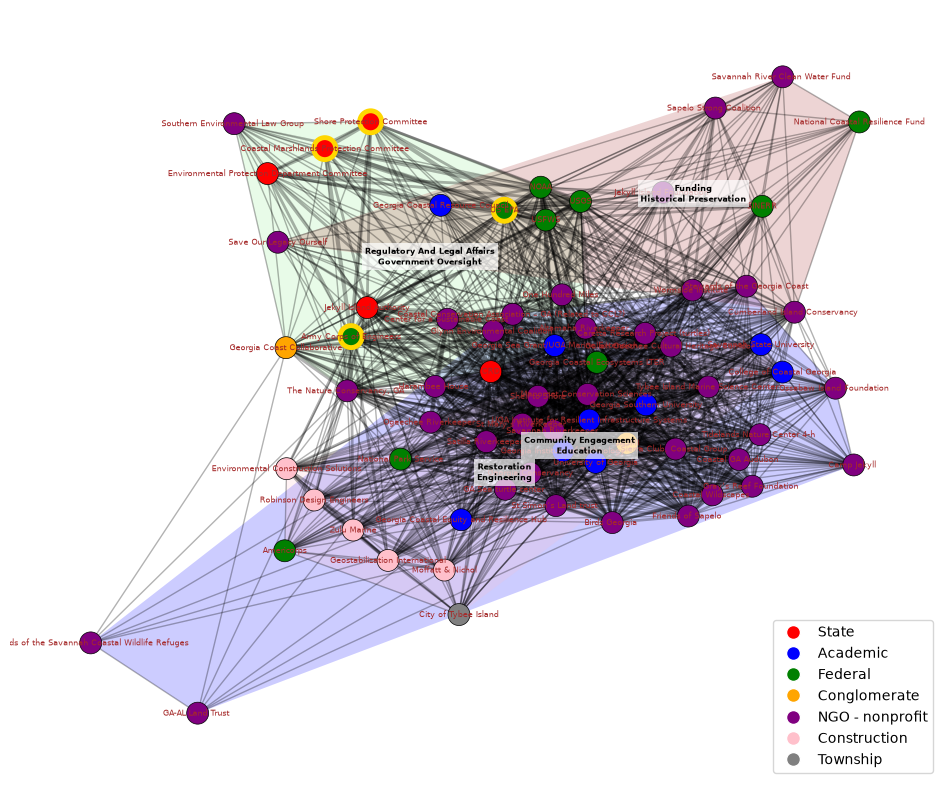

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

pos = nx.spring_layout(
    G,
    k=0.6,
    seed=3
)

edge_widths = [
    G[u][v]["weight"]
    for u, v in G.edges()
]

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.3
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    edgecolors=node_edgecolors,
    linewidths=node_linewidths,
    # node_size=node_sizes,
    node_size=250
)

nx.draw_networkx_labels(
    G,
    pos,
    font_color = 'brown',
    font_size=6
)

from matplotlib.lines import Line2D

legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color,
        markersize=10,
        label=org
    )
    for org, color in palette.items()
]

plt.legend(handles=legend)

edge_widths = [
    G[u][v]["weight"] * 1.5
    for u, v in G.edges()
]

centrality = nx.degree_centrality(G)

node_sizes = [
    300 + 3000 * centrality[n]
    for n in G.nodes
]

from networkx.algorithms.community import greedy_modularity_communities

communities = greedy_modularity_communities(G, weight = "weight")

from collections import Counter

community_missions = {}

for i, community in enumerate(communities):

    missions = []

    for org in community:
        row = df[df["Nodes"] == org]
        missions.extend(row.iloc[0]["Mission type"])

    community_missions[i] = Counter(missions)

##ADDING LABELS
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
import numpy as np
ax = plt.gca()

colors = ['blue','lightgreen','pink','brown',
          'purple','red']

for i, community in enumerate(communities):

    # Coordinates of nodes in this community
    points = np.array([pos[node] for node in community])

    if len(points) < 3:
        continue

    # Draw hull
    hull = ConvexHull(points)

    polygon = Polygon(
        points[hull.vertices],
        facecolor=colors[i % len(colors)],
        edgecolor='none',
        alpha=0.20,
        zorder=0
    )

    ax.add_patch(polygon)

    # Community centroid
    center = points.mean(axis=0)

    # Top three mission types
    top2 = community_missions[i].most_common(2)

    label = "\n".join(
        mission.title() for mission, count in top2
    )

    ax.text(
        center[0],
        center[1],
        label,
        fontsize=6,
        ha='center',
        va='center',
        weight='bold',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='none',
            pad=2
        )
    )



plt.axis("off")
plt.show()

In [9]:
# Sort nodes by degree in descending order
nodes_sorted_by_degree = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)

# Print node name along with its connection count
for node in nodes_sorted_by_degree:
    print(f"{node}: {G.degree(node)} connections")


    ##ADD GCE LTER????

CRD: 62 connections
Shell to Shore: 59 connections
Georgia Sea Grant/UGA Marine Extension: 58 connections
Manomet Conservation Sciences : 58 connections
Georgia Coastal Ecosystems LTER: 56 connections
Altamaha Riverkeeper : 55 connections
Georgia Conservancy: 54 connections
St Simon’s Land trust : 54 connections
Caretta Research Project (turtles) : 53 connections
Glynn Environmental Coalition : 53 connections
Gullah Geechee Cultural Heritage Corridor : 53 connections
Savannah Riverkeeper : 53 connections
St Mary’s Riverkeeper : 53 connections
University of Georgia: 51 connections
Georgia Institute of Technology: 51 connections
Georgia Southern University: 51 connections
UGA Institute for Resilient Infrastructure Systems: 51 connections
One Hundred Miles : 50 connections
Satilla Riverkeeper : 50 connections
Coastal Conservation Association – GA (Related to CCL?) : 48 connections
The Nature Conservancy, GA : 48 connections
Wormsloe Institute : 47 connections
Tybee Island Marine Science C

In [10]:
community_missions[0].most_common(1)

[('community engagement', 23)]

In [11]:
# from collections import Counter

# community_missions = {}

# for i, comm in enumerate(communities):
#     missions = []

#     for org in comm:
#         row = df[df["Nodes"] == org]
#         missions.extend(row.iloc[0]["Mission type"])

#     community_missions[i] = Counter(missions)

for i, counter in community_missions.items():
    print(f"\nCommunity {i}")
    for mission, count in counter.most_common():
        print(f"{mission:20} {count}")


Community 0
community engagement 23
education            21
advocacy and awareness 12
restoration          9
monitoring and assessment 8
land protection      6
funding              5
capacity building and technical assistance 5
research             5
historical preservation 2
economic development 2
engineering          1

Community 1
regulatory and legal affairs 18
government oversight 10
advocacy and awareness 5
research             5
restoration          4
education            4
funding              4
permitting           4
monitoring and assessment 3
community engagement 3
land protection      2
engineering          2
capacity building and technical assistance 2

Community 2
restoration          12
engineering          9
research             7
education            7
funding              1

Community 3
funding              7
historical preservation 4
education            2
research             2
monitoring and assessment 1
capacity building and technical assistance 1


In [12]:
mission_counts = (
    df
    .explode("Mission type")
    ["Mission type"]
    .value_counts()
)

print(mission_counts)

Mission type
education                                     34
community engagement                          26
restoration                                   25
research                                      19
regulatory and legal affairs                  18
funding                                       17
advocacy and awareness                        17
engineering                                   12
monitoring and assessment                     12
government oversight                          10
capacity building and technical assistance     8
land protection                                8
historical preservation                        6
permitting                                     4
economic development                           2
Name: count, dtype: int64


In [ ]:
#Fin